# Phase 5: Create Embeddings

**Project:** Hospital Patient Helpdesk Chatbot  
**Purpose:** Convert approved Phase 4 text chunks into reproducible vectors for semantic retrieval.

This notebook imports `04_embeddings/05_create_embeddings.py`, which remains the single source of truth for embedding behavior. The default provider is local, deterministic, and does not transmit hospital text to an external API.

## Input and output contract

**Input:** `01_data/processed/04_enriched_chunks.json`.

**Data outputs:** `05_embeddings.json`, `05_embedding_manifest.json`, `05_embedding_report.json`, `05_embedding_audit.csv`, and `05_failed_embeddings.json`.

**Plot outputs:** `plots/05_embedding_norm_distribution.png` and `plots/05_cosine_similarity_distribution.png`.

## Embedding method

The development provider tokenizes normalized text, creates word and adjacent-word features, maps each feature into a stable vector position with BLAKE2 hashing, applies signed log-frequency weights, and L2-normalizes the result. The default vector dimension is 384.

This offline baseline is ideal for reproducible development and privacy-conscious demonstrations. A production semantic model can later implement the same input/output contract.

In [2]:
from __future__ import annotations

import importlib.util
import json
import math
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    """Locate the project from the workspace, project, or notebooks folder."""
    start = start.resolve()
    candidates = []
    for directory in (start, *start.parents):
        candidates.extend((directory, directory / "hospital_patient_helpdesk_chatbot"))
    for candidate in candidates:
        module = candidate / "04_embeddings" / "05_create_embeddings.py"
        input_file = candidate / "01_data" / "processed" / "04_enriched_chunks.json"
        if module.is_file() and input_file.is_file():
            return candidate
    raise FileNotFoundError(
        "Could not locate the hospital_patient_helpdesk_chatbot project. "
        "Open this notebook from the project workspace or keep it under 13_notebooks."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
INPUT_PATH = PROJECT_ROOT / "01_data" / "processed" / "04_enriched_chunks.json"
OUTPUT_DIR = PROJECT_ROOT / "01_data" / "processed"
MODULE_PATH = PROJECT_ROOT / "04_embeddings" / "05_create_embeddings.py"

spec = importlib.util.spec_from_file_location("create_embeddings", MODULE_PATH)
embeddings = importlib.util.module_from_spec(spec)
assert spec and spec.loader
sys.modules[spec.name] = embeddings
spec.loader.exec_module(embeddings)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input file: {INPUT_PATH}")
print(f"Embedding module: {MODULE_PATH}")

Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
Input file: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\04_enriched_chunks.json
Embedding module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\04_embeddings\05_create_embeddings.py


## 1. Load and validate enriched chunks

The loader verifies that each record contains text, stable chunk/document IDs, source provenance, and the Phase 4 retrieval metadata object required by later filtering and citation stages.

In [3]:
chunks = embeddings.load_enriched_chunks(INPUT_PATH)
print(f"Chunks loaded: {len(chunks)}")
print(json.dumps({
    "chunk_id": chunks[0]["chunk_id"],
    "source_file": chunks[0]["source_file"],
    "department": chunks[0]["retrieval_metadata"]["department"],
    "text_preview": chunks[0]["text"][:120],
}, indent=2))

Chunks loaded: 102
{
  "chunk_id": "database-hospital-helpdesk-db-0001-chunk-001",
  "source_file": "database/hospital_helpdesk.db",
  "department": "Emergency Department",
  "text_preview": "name: Emergency Department | location: Ground Floor, East Wing | phone: 555-0100 | hours: 24 hours | services: Emergency"
}


## 2. Configure and preview embedding generation

`EmbeddingConfig` validates dimension and batch size. The preview confirms the expected vector shape and unit norm before the full run writes any artifacts.

In [4]:
config = embeddings.EmbeddingConfig(dimension=384, batch_size=32, include_bigrams=True)
preview_vector = embeddings.embed_text(chunks[0]["text"], config)
preview_norm = math.sqrt(sum(value * value for value in preview_vector))
print(f"Model: {embeddings.MODEL_NAME}")
print(f"Dimension: {len(preview_vector)}")
print(f"L2 norm: {preview_norm:.8f}")
print(f"First 12 values: {preview_vector[:12]}")

Model: local-hashing-embedding-v1
Dimension: 384
L2 norm: 0.99999998
First 12 values: [0.0, 0.0, 0.15668382, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## 3. Run the shared Phase 5 pipeline

The module embeds records in batches, isolates failures, validates one-to-one ID coverage and unit norms, writes the complete vectors and lightweight manifest, and generates diagnostics.

In [5]:
result = embeddings.run_embedding_creation(INPUT_PATH, OUTPUT_DIR, config)
embeddings.print_result(result)

Embedding creation completed successfully.
Input chunks: 102
Embeddings created: 102
Failed embeddings: 0

Output files:
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_embeddings.json (560,491 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_embedding_manifest.json (48,903 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_embedding_report.json (1,046 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_embedding_audit.csv (14,528 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_failed_embeddings.json (2 bytes)
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plots

## 4. Validate vectors and provenance

Validation confirms unique chunk IDs, 384 finite values per vector, approximate unit norm, exact input coverage, and unchanged source checksums.

In [6]:
records_payload = json.loads(result.embeddings_path.read_text(encoding="utf-8"))
report = json.loads(result.report_path.read_text(encoding="utf-8"))
failed = json.loads(result.failed_path.read_text(encoding="utf-8"))
assert len(records_payload) == len(chunks) == 102
assert len({record["chunk_id"] for record in records_payload}) == len(records_payload)
assert all(len(record["embedding"]) == config.dimension for record in records_payload)
assert all(abs(record["vector_norm"] - 1.0) < 1e-6 for record in records_payload)
assert failed == []
print("Embedding validation passed.")
print(json.dumps(report, indent=2))

Embedding validation passed.
{
  "generated_at_utc": "2026-06-14T19:10:53.030758+00:00",
  "input_file": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\processed\\04_enriched_chunks.json",
  "input_chunks": 102,
  "embeddings_created": 102,
  "failed_embeddings": 0,
  "provider": "local_feature_hashing",
  "model": "local-hashing-embedding-v1",
  "configuration": {
    "dimension": 384,
    "batch_size": 32,
    "include_bigrams": true
  },
  "vector_norm_statistics": {
    "minimum": 0.99999996,
    "maximum": 1.00000004,
    "mean": 1.0
  },
  "sampled_cosine_similarity": {
    "pairs": 500,
    "minimum": -0.107073,
    "maximum": 0.983013,
    "mean": 0.1256,
    "median": 0.088935
  },
  "output_files": [
    "05_embeddings.json",
    "05_embedding_manifest.json",
    "05_embedding_report.json",
    "05_embedding_audit.csv",
    "05_failed_embeddings.json",
    "plots/05_embedding_norm_distribution.png",
    "plots/05_

## 5. Inspect diagnostic plots

The norm plot shows tiny deviations from 1.0 in `1e-8` units because every vector is normalized. The cosine-similarity plot shows how strongly a deterministic sample of chunk pairs overlaps in the hashed feature space.

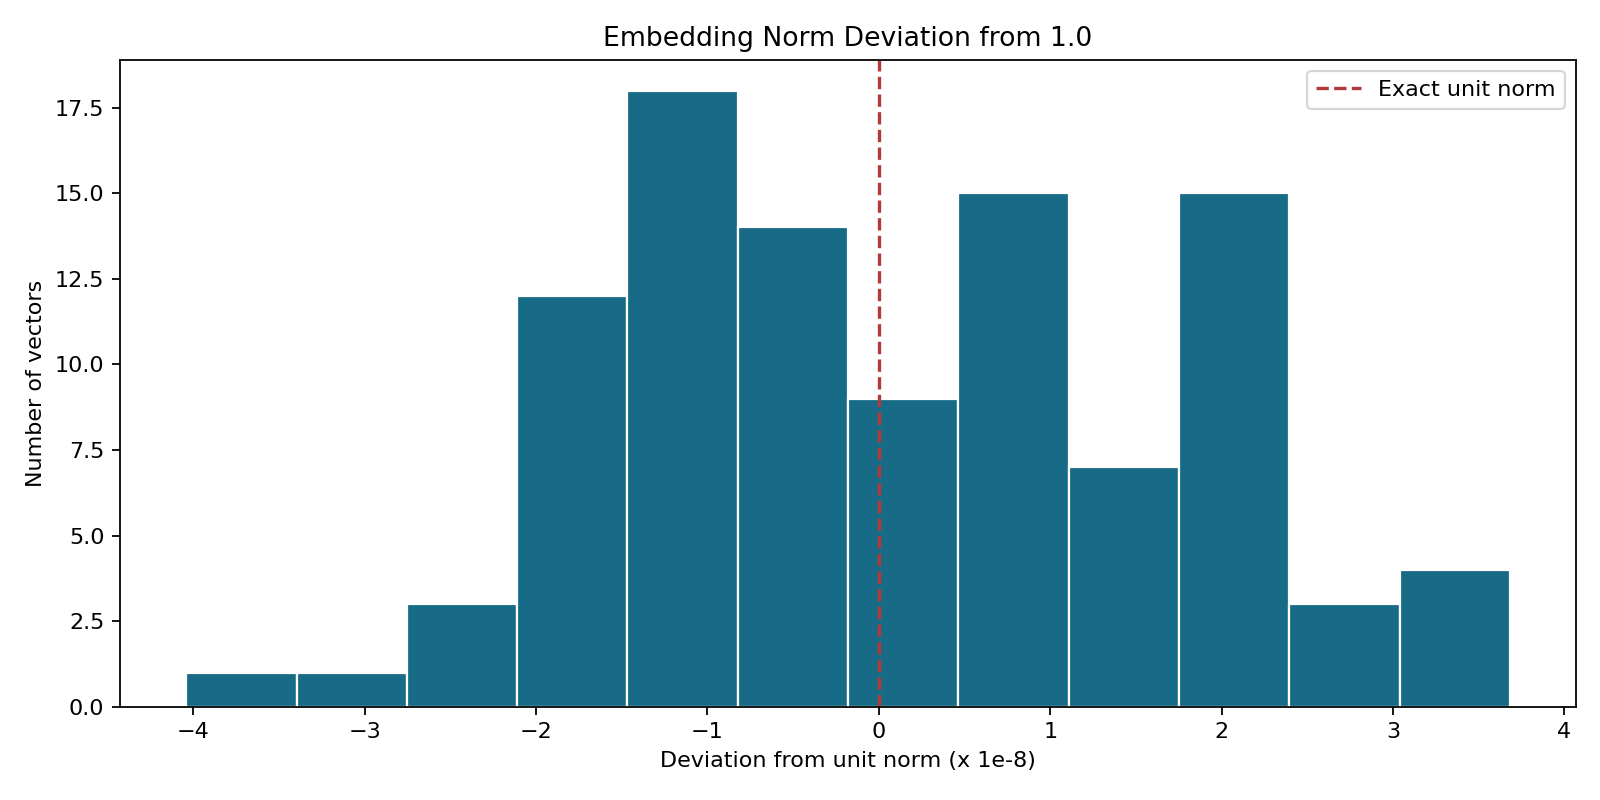

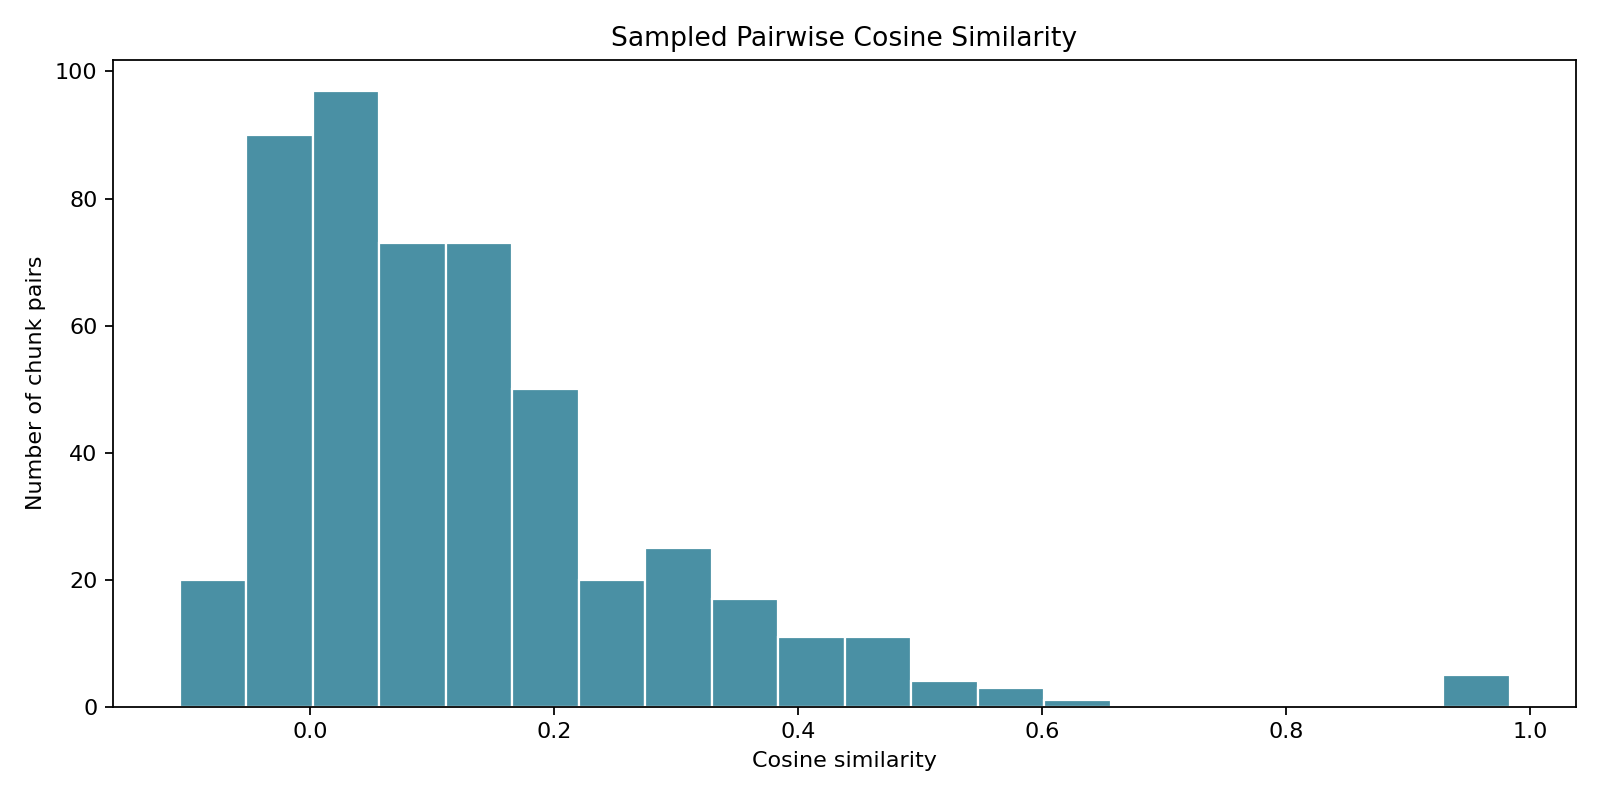

In [7]:
from IPython.display import Image, display
display(Image(filename=str(result.norm_plot_path)))
display(Image(filename=str(result.similarity_plot_path)))

## 6. Output files

The complete vector file feeds Phase 6. The manifest supports quick audits without loading every 384-dimensional vector, while the report, audit, failure file, and plots document quality.

In [8]:
print("Output files:")
for path in (
    result.embeddings_path, result.manifest_path, result.report_path,
    result.audit_path, result.failed_path, result.norm_plot_path,
    result.similarity_plot_path,
):
    print(f"- {path}: {path.stat().st_size:,} bytes")

Output files:
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_embeddings.json: 560,491 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_embedding_manifest.json: 48,903 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_embedding_report.json: 1,046 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_embedding_audit.csv: 14,528 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\05_failed_embeddings.json: 2 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\plots\05_embedding_norm_distribution.png: 39,453 bytes
- C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\

## Notebook and Python module differences

- The notebook provides guided previews, inline diagnostics, assertions, and explanations for experimentation and review.
- The Python module contains all reusable tokenization, hashing, normalization, batching, validation, reporting, plotting, and CLI logic.
- The notebook imports the module instead of maintaining a second embedding implementation.

## Safety and next step

- The default provider runs locally and does not transmit source text.
- Embeddings encode approved text for retrieval; they do not diagnose, recommend treatment, or generate medical claims.
- Text checksums and source metadata preserve traceability from vector to original chunk.
- Continue with `06_store_vector_index.ipynb` using `05_embeddings.json`.